# Hydrophone acoustic-pressure field plots

One plot per cell, each cell fully self-contained (own imports, own data read,
own styling, own save) so you can run and tweak any single plot without
touching the others.

- **3D aneurysm-channel scan** — 2 MHz, 30 Vpp, XY plane at Z = 13 mm (24 points).
- **quasi-2D PDMS scan** — 1.7 MHz, 20 Vpp, XY cross at Z = 6 mm + short Z depth scan.

Pressures are **final** (peak-to-peak): no booster amplifier was in the signal
chain, so no gain correction is applied. `P_pp[kPa] = Vpp[mV] / S * 1000` with
S = 654.0046 mV/MPa (2 MHz) and 655.63 mV/MPa (1.7 MHz).

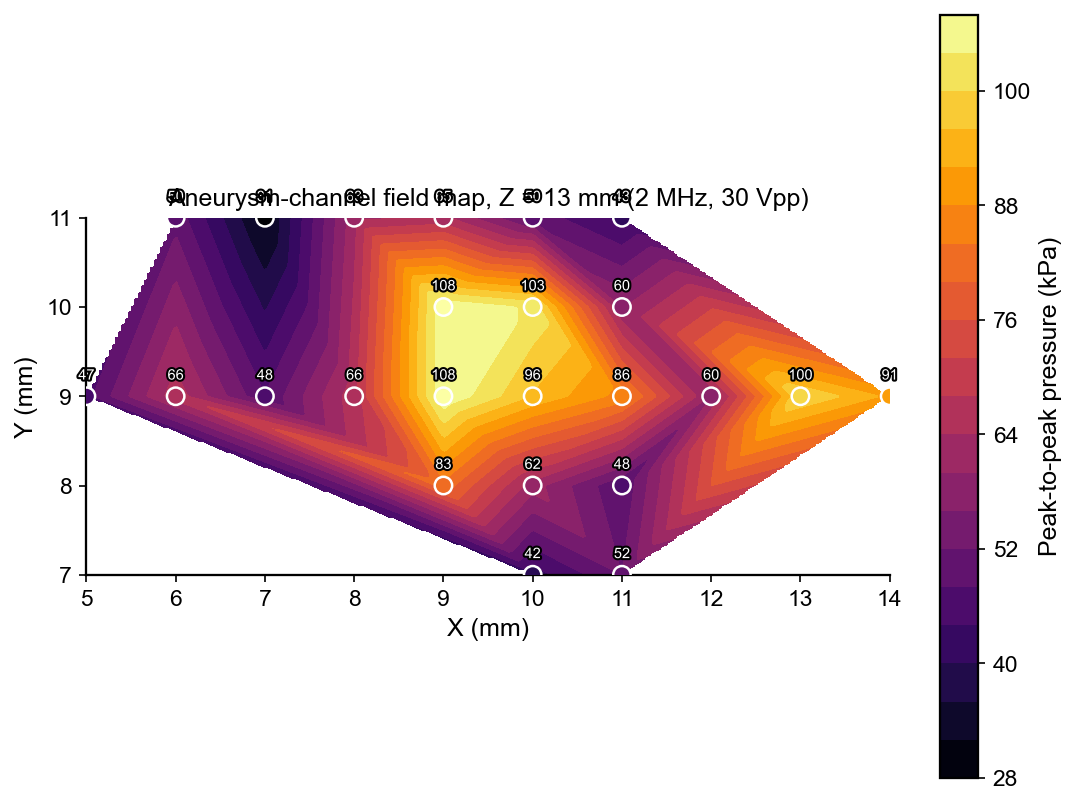

In [1]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# 3D aneurysm scan (2 MHz) — interpolated 2D pressure field map at Z = 13 mm
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.tri import Triangulation, LinearTriInterpolator
import matplotlib.patheffects as pe

df = pd.read_csv("../data/hydrophone_acoustic_pressure/3D_aneurysm_channel_scan/data_table.csv")
x, y, p = df["X_mm"].values, df["Y_mm"].values, df["Pressure_pp_kPa"].values

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(7.5, 5.5))
tri = Triangulation(x, y)
interp = LinearTriInterpolator(tri, p)
xi = np.linspace(x.min(), x.max(), 250)
yi = np.linspace(y.min(), y.max(), 250)
Xi, Yi = np.meshgrid(xi, yi)
Pi = interp(Xi, Yi)

cf = ax.contourf(Xi, Yi, Pi, levels=20, cmap="inferno")
cb = fig.colorbar(cf, ax=ax); cb.set_label("Peak-to-peak pressure (kPa)")
ax.scatter(x, y, c=p, cmap="inferno", edgecolors="white", linewidths=1.2, s=70, zorder=3)
for xx, yy, pp in zip(x, y, p):
    ax.annotate(f"{pp:.0f}", (xx, yy), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7, color="white",
                path_effects=[pe.withStroke(linewidth=2, foreground="black")])
ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_aspect("equal")
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_3d_field_map.png"); fig.savefig("hydrophone_figures/hydro_3d_field_map.pdf")
plt.show()

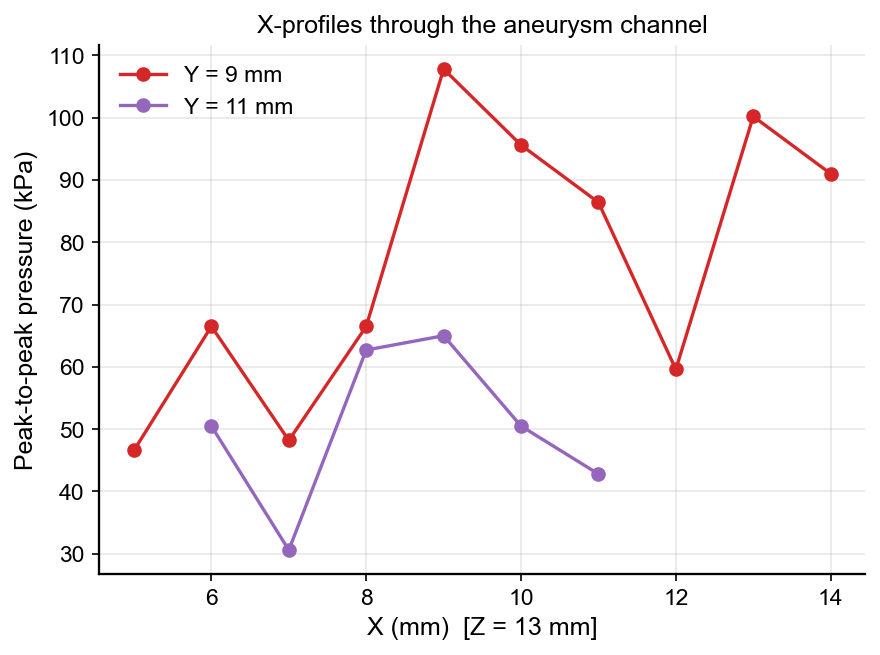

In [2]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# 3D aneurysm scan — X-profile cuts (rows Y = 9 and Y = 11)
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../data/hydrophone_acoustic_pressure/3D_aneurysm_channel_scan/data_table.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(6, 4.5))
for yfix, color, lab in [(9, "#d62728", "Y = 9 mm"), (11, "#9467bd", "Y = 11 mm")]:
    sub = df[df["Y_mm"] == yfix].sort_values("X_mm")
    ax.plot(sub["X_mm"], sub["Pressure_pp_kPa"], "o-", color=color, lw=1.6, label=lab)
ax.set_xlabel("X (mm)  [Z = 13 mm]"); ax.set_ylabel("Peak-to-peak pressure (kPa)")
ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_3d_xprofiles.png"); fig.savefig("hydrophone_figures/hydro_3d_xprofiles.pdf")
plt.show()

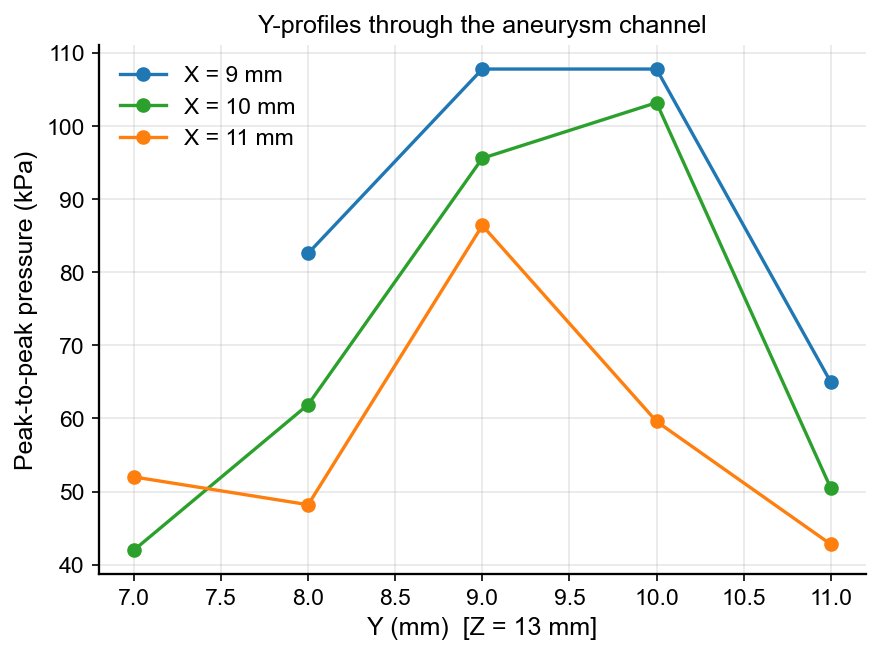

In [3]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# 3D aneurysm scan — Y-profile cuts (columns X = 9, 10, 11)
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../data/hydrophone_acoustic_pressure/3D_aneurysm_channel_scan/data_table.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(6, 4.5))
for xfix, color, lab in [(9, "#1f77b4", "X = 9 mm"), (10, "#2ca02c", "X = 10 mm"), (11, "#ff7f0e", "X = 11 mm")]:
    sub = df[df["X_mm"] == xfix].sort_values("Y_mm")
    ax.plot(sub["Y_mm"], sub["Pressure_pp_kPa"], "o-", color=color, lw=1.6, label=lab)
ax.set_xlabel("Y (mm)  [Z = 13 mm]"); ax.set_ylabel("Peak-to-peak pressure (kPa)")
ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_3d_yprofiles.png"); fig.savefig("hydrophone_figures/hydro_3d_yprofiles.pdf")
plt.show()

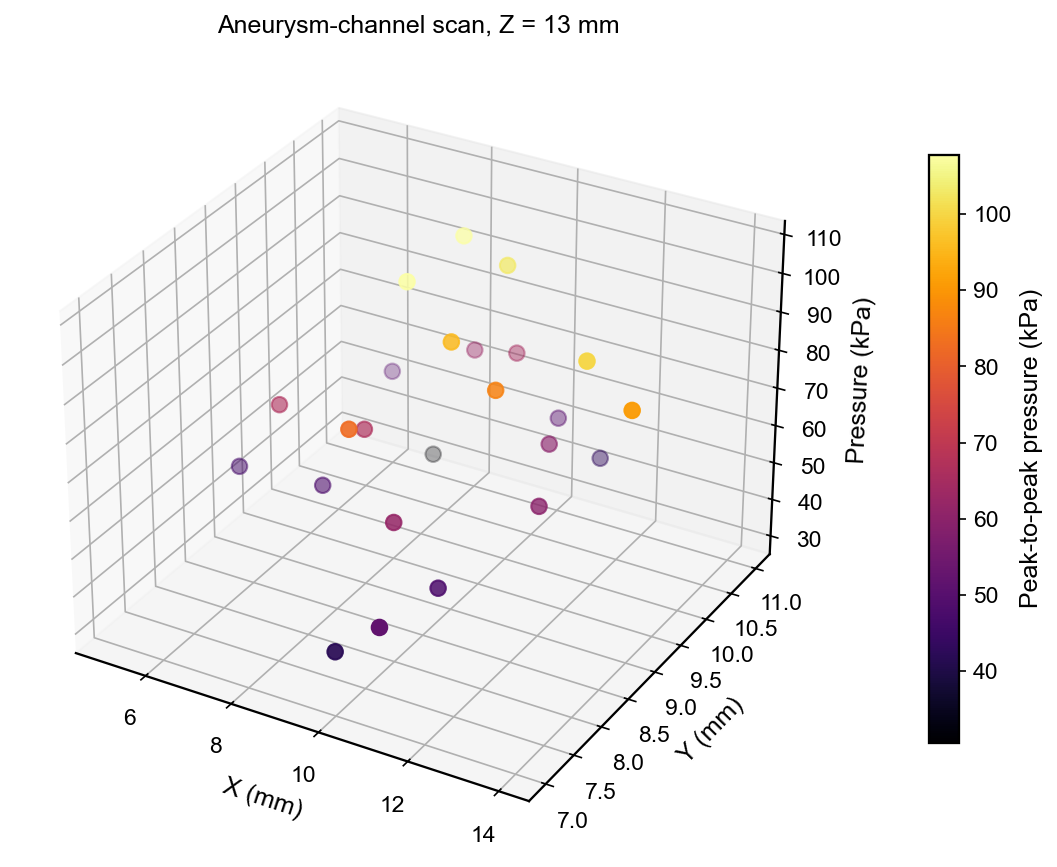

In [4]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# 3D aneurysm scan — 3D scatter of all 24 points (pressure as height + colour)
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3d projection)

df = pd.read_csv("../data/hydrophone_acoustic_pressure/3D_aneurysm_channel_scan/data_table.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(df["X_mm"], df["Y_mm"], df["Pressure_pp_kPa"],
                c=df["Pressure_pp_kPa"], cmap="inferno", s=55, depthshade=True)
fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7, label="Peak-to-peak pressure (kPa)")
ax.set_xlabel("X (mm)", labelpad=10); ax.set_ylabel("Y (mm)", labelpad=10); ax.set_zlabel("Pressure (kPa)", labelpad=10)
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_3d_scatter.png"); fig.savefig("hydrophone_figures/hydro_3d_scatter.pdf")
plt.show()

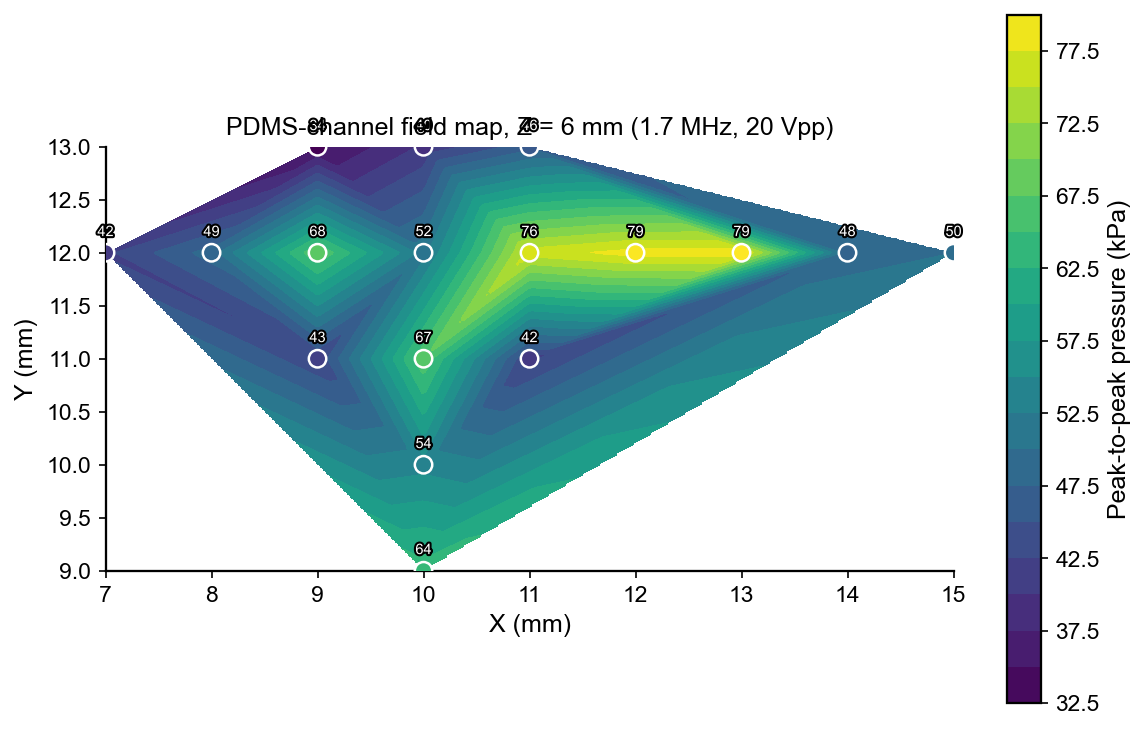

In [5]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# quasi-2D PDMS scan (1.7 MHz) — 2D pressure field map at Z = 6 mm
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.tri import Triangulation, LinearTriInterpolator
import matplotlib.patheffects as pe

df = pd.read_csv("../data/hydrophone_acoustic_pressure/quasi2D_pdms_channel_scan/data_table.csv")
d6 = df[df["Z_mm"] == 6]                      # the XY plane (drop the Z depth points)
x, y, p = d6["X_mm"].values, d6["Y_mm"].values, d6["Pressure_pp_kPa"].values

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(8, 5))
tri = Triangulation(x, y)
interp = LinearTriInterpolator(tri, p)
xi = np.linspace(x.min(), x.max(), 250)
yi = np.linspace(y.min(), y.max(), 250)
Xi, Yi = np.meshgrid(xi, yi)
Pi = interp(Xi, Yi)

cf = ax.contourf(Xi, Yi, Pi, levels=20, cmap="viridis")
cb = fig.colorbar(cf, ax=ax); cb.set_label("Peak-to-peak pressure (kPa)")
ax.scatter(x, y, c=p, cmap="viridis", edgecolors="white", linewidths=1.2, s=70, zorder=3)
for xx, yy, pp in zip(x, y, p):
    ax.annotate(f"{pp:.0f}", (xx, yy), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7, color="white",
                path_effects=[pe.withStroke(linewidth=2, foreground="black")])
ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_aspect("equal")
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_2d_field_map.png"); fig.savefig("hydrophone_figures/hydro_2d_field_map.pdf")
plt.show()

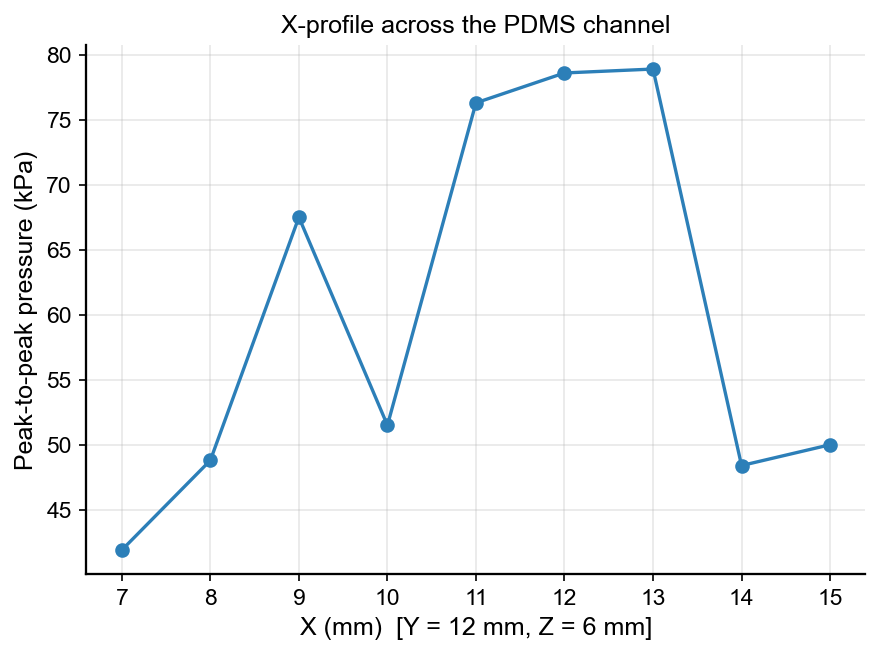

In [6]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# quasi-2D PDMS scan — X-profile along the main scan row (Y = 12 mm, Z = 6 mm)
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../data/hydrophone_acoustic_pressure/quasi2D_pdms_channel_scan/data_table.csv")
sub = df[(df["Y_mm"] == 12) & (df["Z_mm"] == 6)].sort_values("X_mm")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(sub["X_mm"], sub["Pressure_pp_kPa"], "o-", color="#2c7fb8", lw=1.6)
ax.set_xlabel("X (mm)  [Y = 12 mm, Z = 6 mm]"); ax.set_ylabel("Peak-to-peak pressure (kPa)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_2d_xprofile.png"); fig.savefig("hydrophone_figures/hydro_2d_xprofile.pdf")
plt.show()

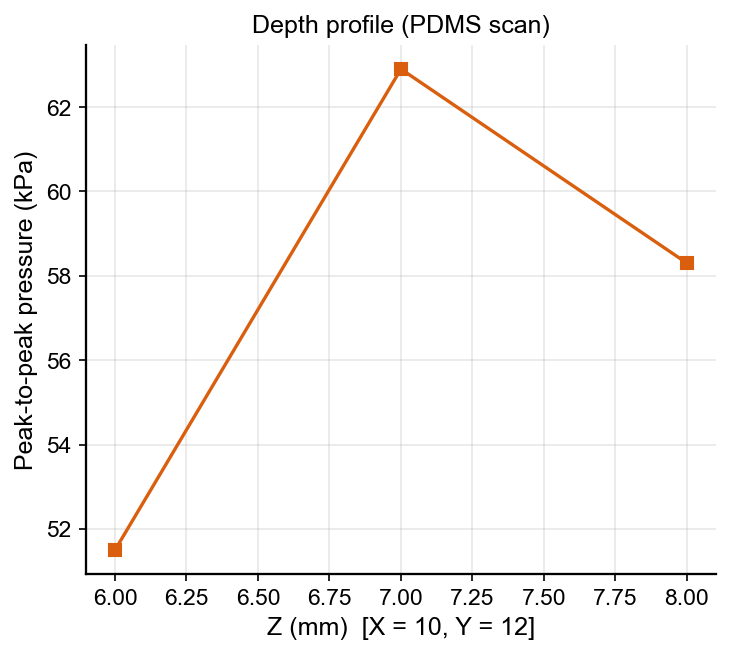

In [7]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# quasi-2D PDMS scan — depth (Z) profile at X = 10, Y = 12
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../data/hydrophone_acoustic_pressure/quasi2D_pdms_channel_scan/data_table.csv")
sub = df[(df["X_mm"] == 10) & (df["Y_mm"] == 12)].sort_values("Z_mm")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(sub["Z_mm"], sub["Pressure_pp_kPa"], "s-", color="#d95f0e", lw=1.6)
ax.set_xlabel("Z (mm)  [X = 10, Y = 12]"); ax.set_ylabel("Peak-to-peak pressure (kPa)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_2d_zprofile.png"); fig.savefig("hydrophone_figures/hydro_2d_zprofile.pdf")
plt.show()

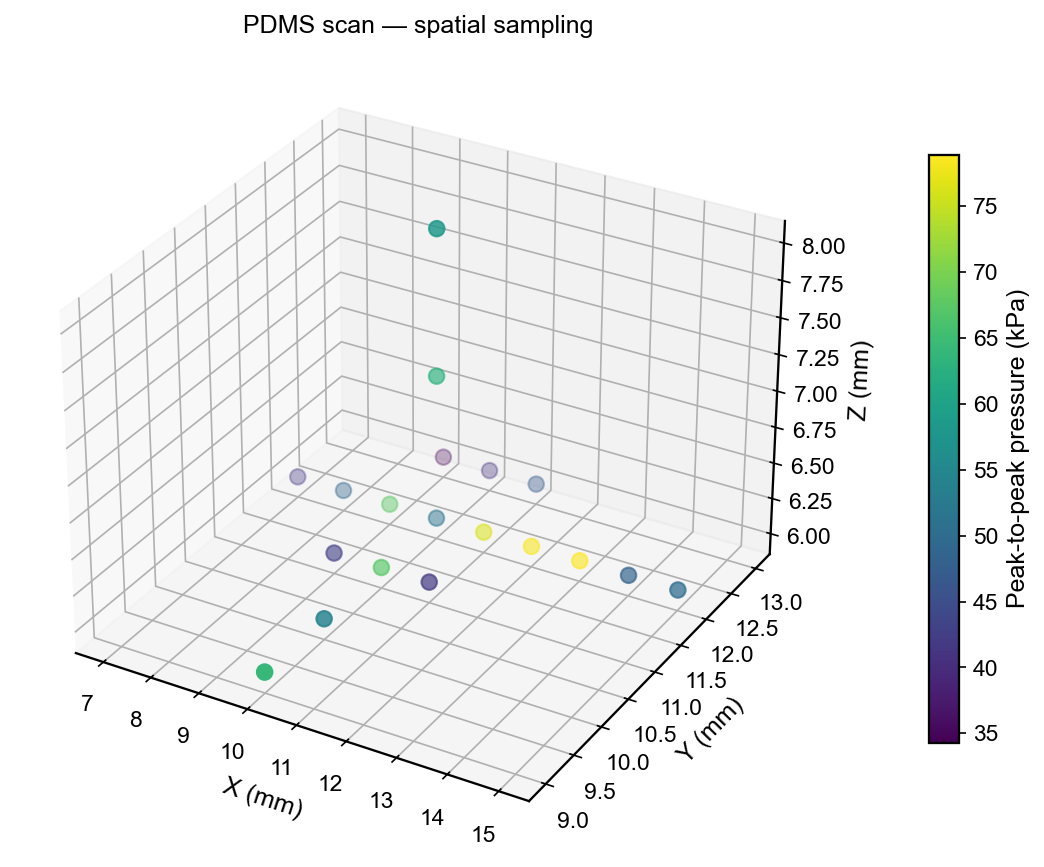

In [8]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# quasi-2D PDMS scan — 3D scatter of all points
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

df = pd.read_csv("../data/hydrophone_acoustic_pressure/quasi2D_pdms_channel_scan/data_table.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(df["X_mm"], df["Y_mm"], df["Z_mm"],
                c=df["Pressure_pp_kPa"], cmap="viridis", s=55)
fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7, label="Peak-to-peak pressure (kPa)")
ax.set_xlabel("X (mm)", labelpad=10); ax.set_ylabel("Y (mm)", labelpad=10); ax.set_zlabel("Z (mm)", labelpad=10)
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_2d_scatter.png"); fig.savefig("hydrophone_figures/hydro_2d_scatter.pdf")
plt.show()

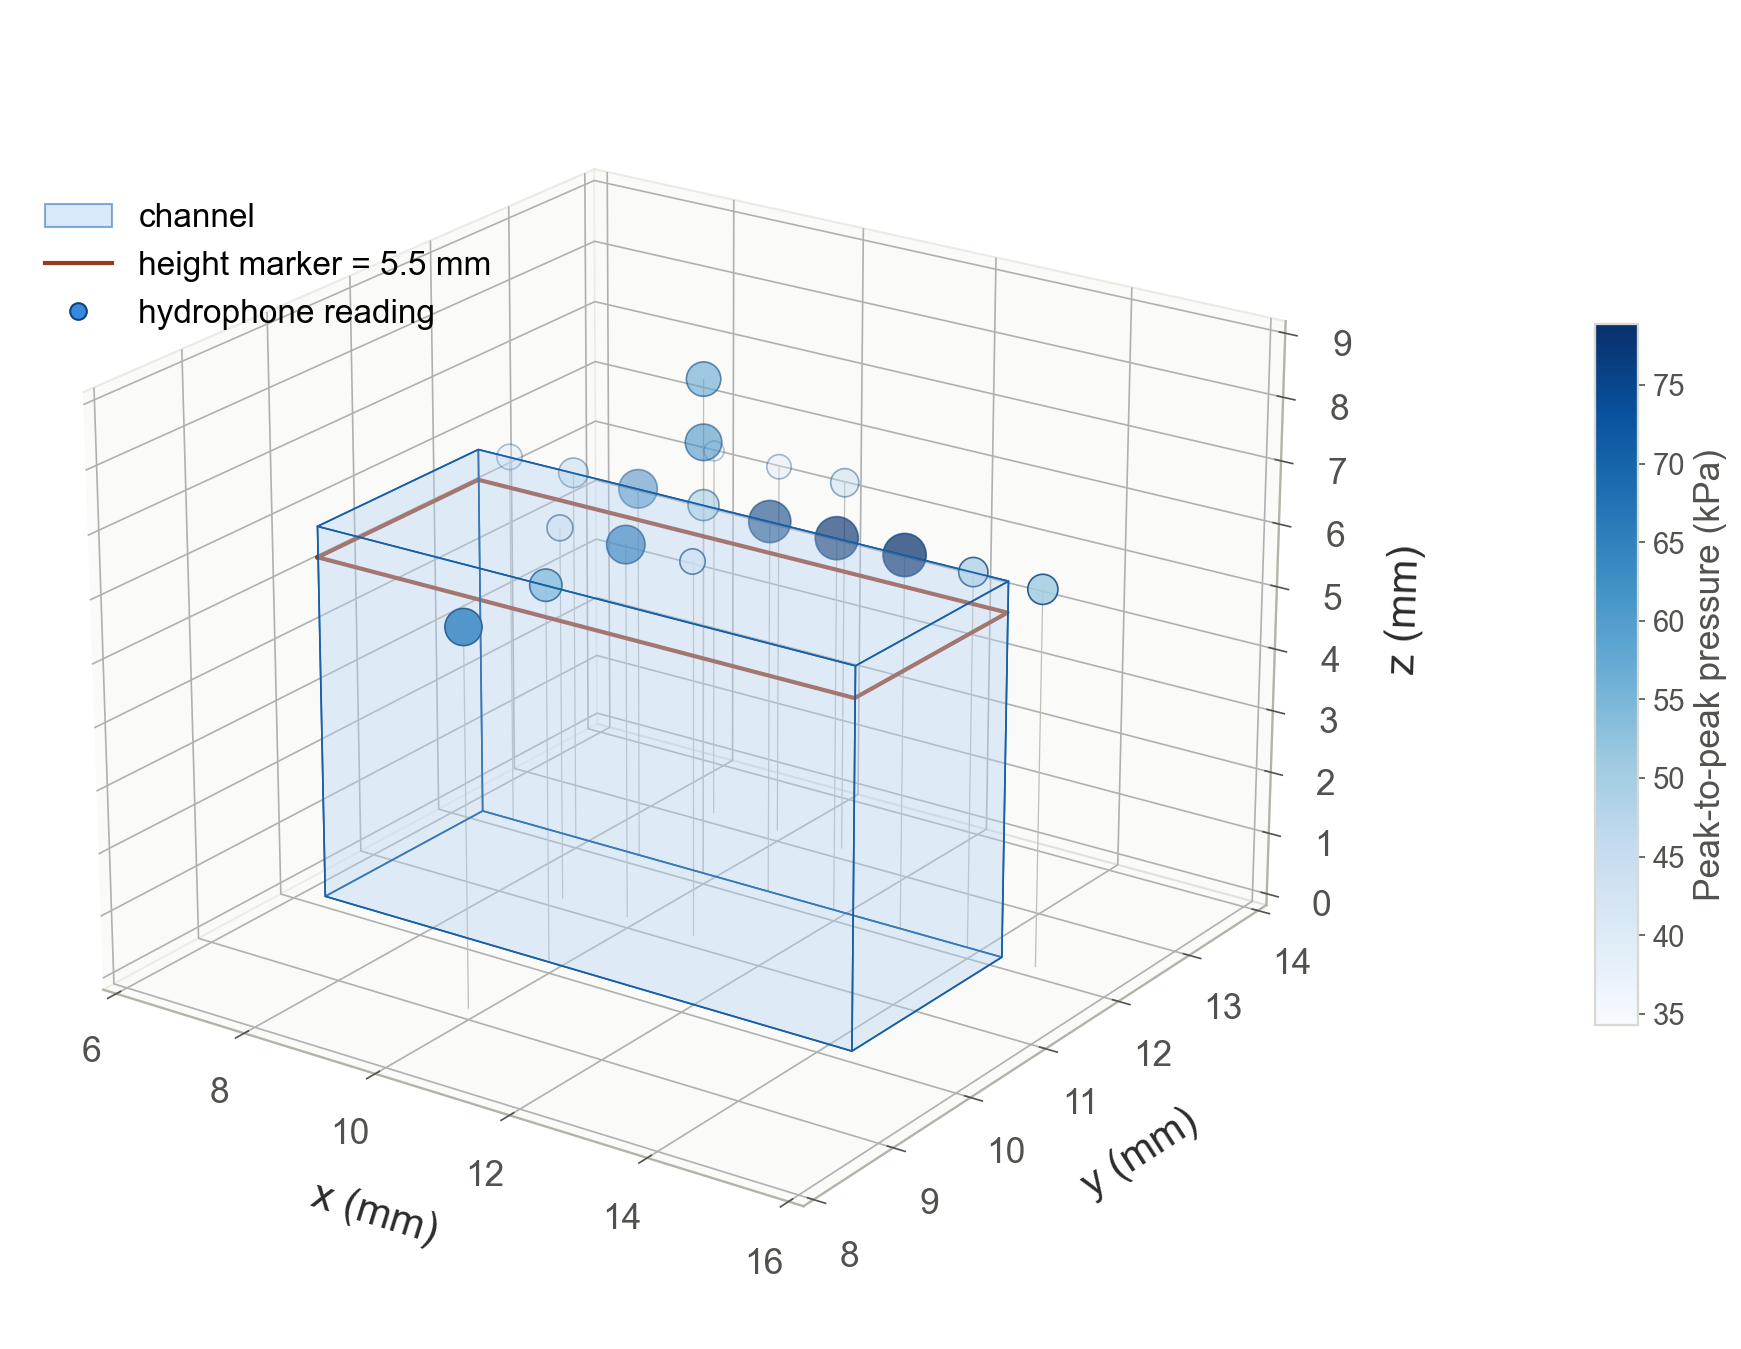

In [18]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# quasi-2D PDMS scan — channel-box 3D scatter (template "v2" style)
# Translucent light-blue channel box; pressure encoded by BOTH marker size and
# Blues colour; gray drop-lines to the floor for depth; view_init(22, -55).
# Self-contained: edit the CONFIG block for your geometry / columns.
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ----------------- CONFIG -----------------
CSV = "../data/hydrophone_acoustic_pressure/quasi2D_pdms_channel_scan/data_table.csv"
X_COL, Y_COL, Z_COL, VALUE_COL = "X_mm", "Y_mm", "Z_mm", "Pressure_pp_kPa"
VALUE_LABEL = "Peak-to-peak pressure (kPa)"
TITLE = "Peak-to-peak pressure vs. channel position\n1.7 MHz, 20 Vpp drive, SN 4746"
BOX_X, BOX_Y, BOX_Z = (6.5, 14.5), (10, 12), (0, 6)   # PDMS channel extent (mm)
HEIGHT_MARKER_Z = 5.5                                  # rust ring at channel height (mm); None to skip
VIEW_ELEV, VIEW_AZIM = 22, -55
OUT = "hydrophone_figures/hydro_2d_channel_style.png"
# ------------------------------------------

df = pd.read_csv(CSV)
xs, ys, zs = df[X_COL].tolist(), df[Y_COL].tolist(), df[Z_COL].tolist()
vals = df[VALUE_COL].tolist()
vmin, vmax = min(vals), max(vals)

mpl.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"]})

fig = plt.figure(figsize=(13, 11), facecolor="white")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((0.97, 0.97, 0.96, 1.0))
    axis.pane.set_edgecolor((0.85, 0.85, 0.82, 1.0))
    axis.line.set_color((0.7, 0.7, 0.66, 1.0))
ax.grid(True, color=(0.88, 0.88, 0.85), linewidth=0.5)
ax.tick_params(colors="#52514e", labelsize=17, pad=8)

zbase, ztop = 0, max(zs) + 1
box_color, edge_color = "#B5D4F4", "#185FA5"

if BOX_X and BOX_Y and BOX_Z:
    x0, x1 = BOX_X; y0, y1 = BOX_Y; z0, z1 = BOX_Z
    faces = [
        [(x0, y0, z0), (x1, y0, z0), (x1, y1, z0), (x0, y1, z0)],
        [(x0, y0, z1), (x1, y0, z1), (x1, y1, z1), (x0, y1, z1)],
        [(x0, y0, z0), (x1, y0, z0), (x1, y0, z1), (x0, y0, z1)],
        [(x0, y1, z0), (x1, y1, z0), (x1, y1, z1), (x0, y1, z1)],
        [(x0, y0, z0), (x0, y1, z0), (x0, y1, z1), (x0, y0, z1)],
        [(x1, y0, z0), (x1, y1, z0), (x1, y1, z1), (x1, y0, z1)],
    ]
    for fpts in faces:
        ax.add_collection3d(Poly3DCollection([fpts], facecolor=box_color,
                            edgecolor=edge_color, linewidth=0.8, alpha=0.22, zorder=1))
    if HEIGHT_MARKER_Z is not None:
        ring = [(x0, y0, HEIGHT_MARKER_Z), (x1, y0, HEIGHT_MARKER_Z),
                (x1, y1, HEIGHT_MARKER_Z), (x0, y1, HEIGHT_MARKER_Z),
                (x0, y0, HEIGHT_MARKER_Z)]
        rx, ry, rz = zip(*ring)
        ax.plot(rx, ry, rz, color="#993C1D", linewidth=2, zorder=2)

for x, y, z in zip(xs, ys, zs):
    ax.plot([x, x], [y, y], [zbase, z], color=(0.75, 0.75, 0.72), linewidth=0.6, zorder=1)

sizes = [90 + (v - vmin) / (vmax - vmin) * 340 for v in vals]
sc = ax.scatter(xs, ys, zs, c=vals, cmap="Blues", s=sizes, edgecolors="#0c447c",
                linewidths=0.8, vmin=vmin, vmax=vmax, depthshade=True, zorder=3)

legend_handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor="#378ADD",
                         markeredgecolor="#0c447c", markersize=8, label="hydrophone reading")]
if BOX_X:
    legend_handles.insert(0, Patch(facecolor=box_color, edgecolor=edge_color,
                                   alpha=0.5, label="channel"))
    if HEIGHT_MARKER_Z is not None:
        legend_handles.insert(1, Line2D([0], [0], color="#993C1D", linewidth=2,
                                        label=f"height marker = {HEIGHT_MARKER_Z} mm"))
ax.legend(handles=legend_handles, loc="upper left", fontsize=16, frameon=False,
          bbox_to_anchor=(0.0, 0.88))

ax.set_xlabel("x (mm)", fontsize=20, color="#2c2c2a", labelpad=22)
ax.set_ylabel("y (mm)", fontsize=20, color="#2c2c2a", labelpad=22)
ax.set_zlabel("z (mm)", fontsize=20, color="#2c2c2a", labelpad=16)
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 1, max(ys) + 1); ax.set_zlim(zbase, ztop)
ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

cbar = fig.colorbar(sc, ax=ax, shrink=0.45, pad=0.14, aspect=16)
cbar.set_label(VALUE_LABEL, fontsize=17, color="#52514e")
cbar.ax.tick_params(labelsize=14, colors="#52514e")
cbar.outline.set_edgecolor((0.85, 0.85, 0.82))

fig.tight_layout(pad=2.0)
fig.savefig(OUT, dpi=180, facecolor="white")
plt.show()

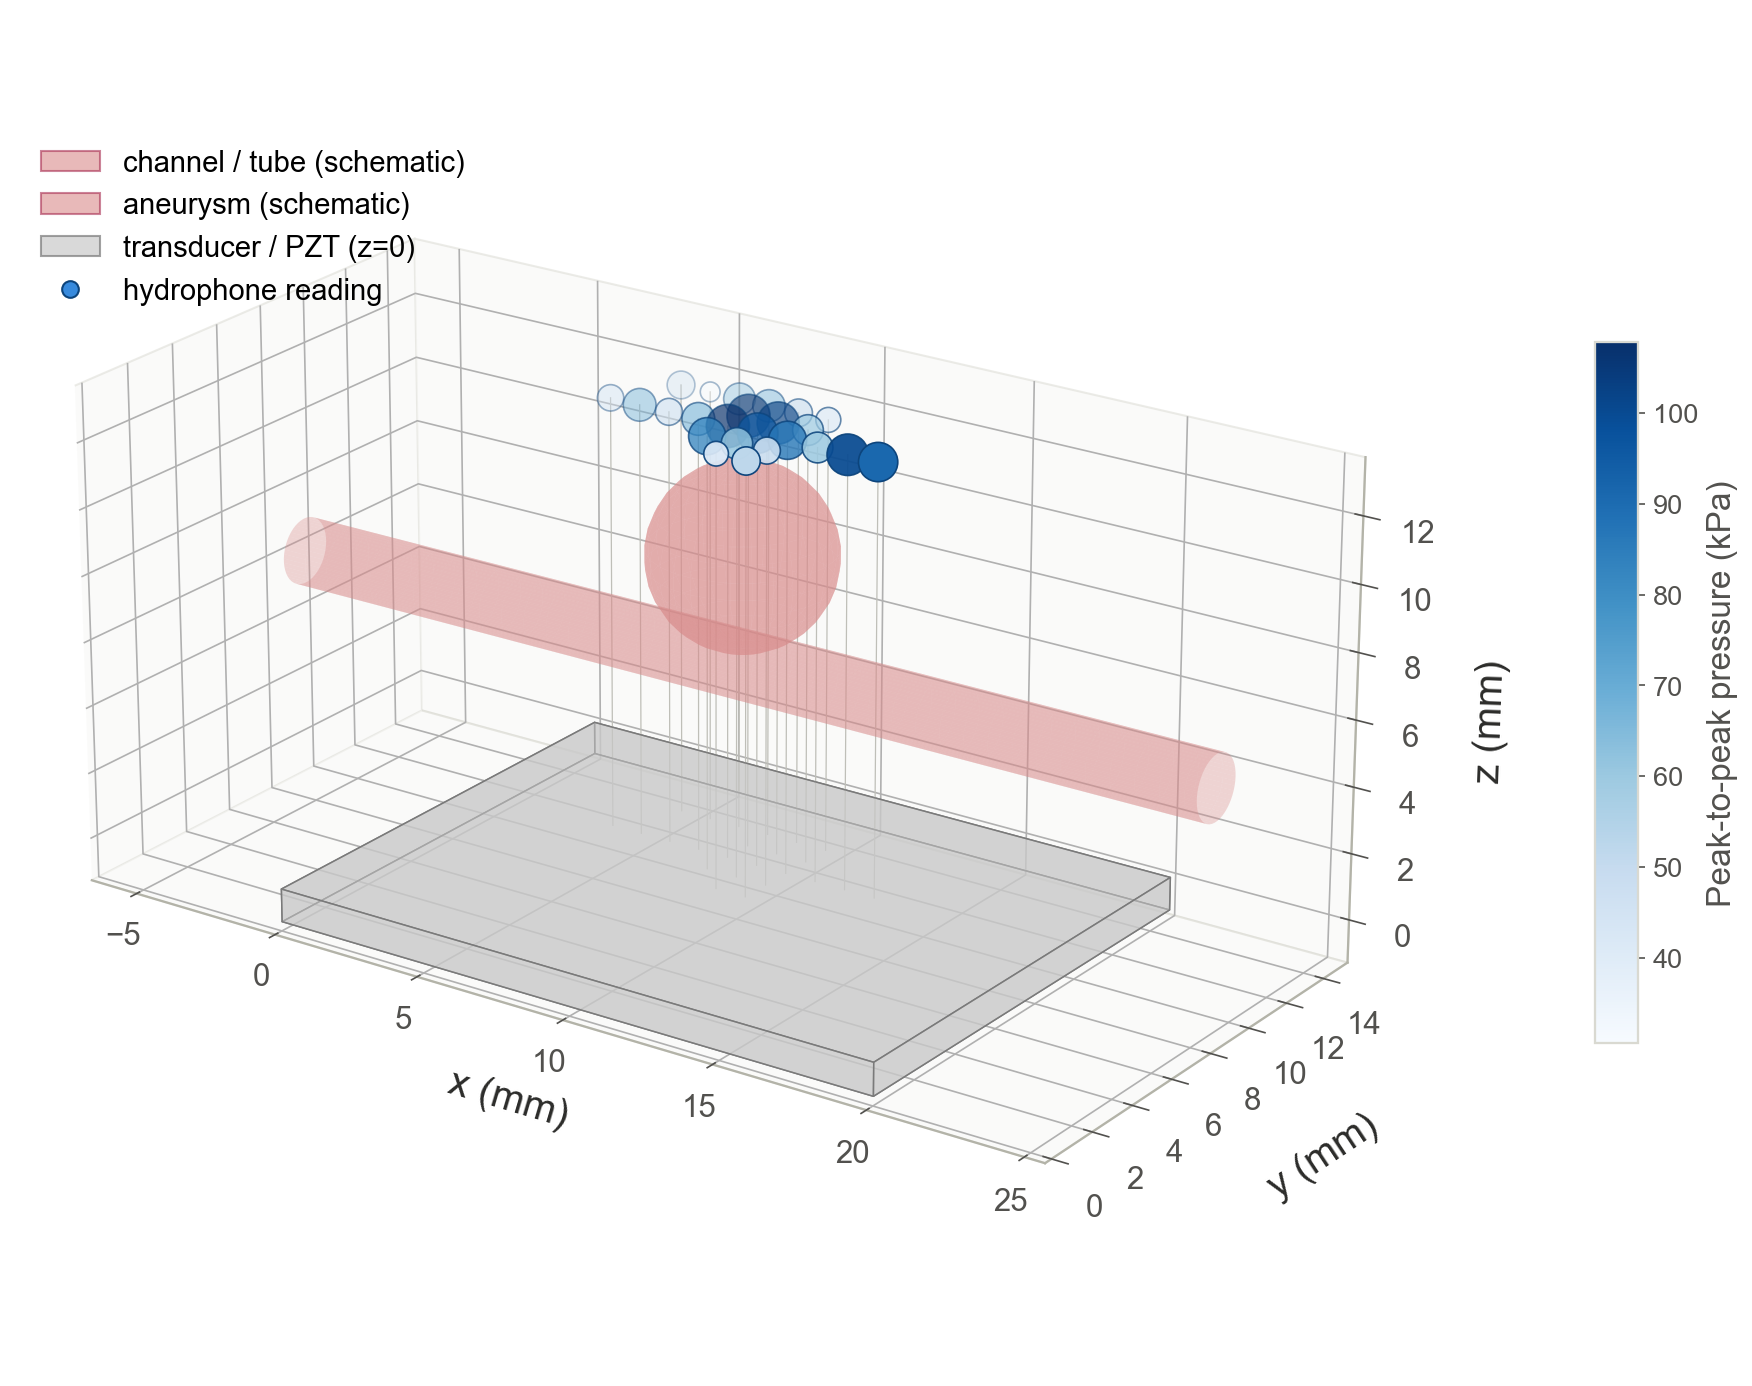

In [17]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# 3D aneurysm scan — channel drawn as a TUBE (cylinder) + aneurysm sphere
# Real pressure scatter (size + Blues colour) sits ABOVE the sealed channel.
# Channel = translucent cylinder along x; aneurysm = sphere bulging off it;
# PZT = gray slab below. Schematic device outline; edit CONFIG.
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ------------------- CONFIG (mm, scan coordinate frame) -------------------
CSV = "../data/hydrophone_acoustic_pressure/3D_aneurysm_channel_scan/data_table.csv"
VALUE_COL, VALUE_LABEL = "Pressure_pp_kPa", "Peak-to-peak pressure (kPa)"
TUBE_X          = (-6.0, 25.0)          # channel tube extent along x (longer than PZT)
TUBE_YC, TUBE_ZC = 9.0, 6.0             # tube axis (y, z): channel at z 5-7 (2 mm dia)
TUBE_R          = 1.0                   # tube radius (2 mm diameter)
ANEURYSM_C, ANEURYSM_R = (9.5, 9.0, 9.25), 2.75  # sac bottom ~6.5, 5.5 mm dia, bulges up from tube
PZT_X, PZT_Y, PZT_Z    = (0.0, 20.0), (0.0, 15.0), (-1.0, 0.0) # transducer: emitting face at z=0 (all z measured from transducer)
PDMS_X, PDMS_Y, PDMS_Z = (-6.0, 25.0), (3.0, 14.0), (0.0, 12.5)  # clear PDMS block enclosing tube + sac
DROP_Z = 0.0                            # droplines from readings down to the transducer face
VIEW_ELEV, VIEW_AZIM = 22, -55
OUT = "hydrophone_figures/hydro_3d_channel_style.png"
# --------------------------------------------------------------------------

df = pd.read_csv(CSV)
xs, ys, zs, vals = df["X_mm"].values, df["Y_mm"].values, df["Z_mm"].values, df[VALUE_COL].values
vmin, vmax = vals.min(), vals.max()

mpl.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"]})
fig = plt.figure(figsize=(13, 11), facecolor="white")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((0.97, 0.97, 0.96, 1.0))
    axis.pane.set_edgecolor((0.85, 0.85, 0.82, 1.0))
    axis.line.set_color((0.7, 0.7, 0.66, 1.0))
ax.grid(True, color=(0.88, 0.88, 0.85), linewidth=0.5)
ax.tick_params(colors="#52514e", labelsize=15, pad=6)

# --- PZT slab (gray box) ---
x0, x1 = PZT_X; y0, y1 = PZT_Y; z0, z1 = PZT_Z
for fp in [
    [(x0,y0,z0),(x1,y0,z0),(x1,y1,z0),(x0,y1,z0)], [(x0,y0,z1),(x1,y0,z1),(x1,y1,z1),(x0,y1,z1)],
    [(x0,y0,z0),(x1,y0,z0),(x1,y0,z1),(x0,y0,z1)], [(x0,y1,z0),(x1,y1,z0),(x1,y1,z1),(x0,y1,z1)],
    [(x0,y0,z0),(x0,y1,z0),(x0,y1,z1),(x0,y0,z1)], [(x1,y0,z0),(x1,y1,z0),(x1,y1,z1),(x1,y0,z1)]]:
    ax.add_collection3d(Poly3DCollection([fp], facecolor="#c9c9c9", edgecolor="#7a7a7a",
                                         linewidth=0.7, alpha=0.55, zorder=1))

# --- clear PDMS block around the channel ---
px0, px1 = PDMS_X; py0, py1 = PDMS_Y; pz0, pz1 = PDMS_Z
for fp in [
    [(px0,py0,pz0),(px1,py0,pz0),(px1,py1,pz0),(px0,py1,pz0)], [(px0,py0,pz1),(px1,py0,pz1),(px1,py1,pz1),(px0,py1,pz1)],
    [(px0,py0,pz0),(px1,py0,pz0),(px1,py0,pz1),(px0,py0,pz1)], [(px0,py1,pz0),(px1,py1,pz0),(px1,py1,pz1),(px0,py1,pz1)],
    [(px0,py0,pz0),(px0,py1,pz0),(px0,py1,pz1),(px0,py0,pz1)], [(px1,py0,pz0),(px1,py1,pz0),(px1,py1,pz1),(px1,py0,pz1)]]:
    ax.add_collection3d(Poly3DCollection([fp], facecolor="#B5D4F4", edgecolor="#185FA5",
                                         linewidth=0.6, alpha=0.12, zorder=0))

# --- channel as a cylinder (tube) along x ---
th = np.linspace(0, 2*np.pi, 48)
xl = np.linspace(TUBE_X[0], TUBE_X[1], 80)
Th, Xc = np.meshgrid(th, xl)
Yc = TUBE_YC + TUBE_R*np.cos(Th)
Zc = TUBE_ZC + TUBE_R*np.sin(Th)
ax.plot_surface(Xc, Yc, Zc, color="#d98b8b", alpha=0.35, linewidth=0,
                antialiased=True, shade=False, zorder=2)

# --- aneurysm sac (translucent sphere bulging off the tube) ---
cx, cy, cz = ANEURYSM_C
u = np.linspace(0, 2*np.pi, 30); vv = np.linspace(0, np.pi, 18)
sx = cx + ANEURYSM_R*np.outer(np.cos(u), np.sin(vv))
sy = cy + ANEURYSM_R*np.outer(np.sin(u), np.sin(vv))
sz = cz + ANEURYSM_R*np.outer(np.ones_like(u), np.cos(vv))
ax.plot_surface(sx, sy, sz, color="#d98b8b", alpha=0.45, linewidth=0, shade=False, zorder=2)

# --- depth-cue drop lines from readings down to the PZT ---
for x, y, z in zip(xs, ys, zs):
    ax.plot([x, x], [y, y], [DROP_Z, z], color=(0.75, 0.75, 0.72), linewidth=0.6, zorder=3)

sizes = 90 + (vals - vmin) / (vmax - vmin) * 340
sc = ax.scatter(xs, ys, zs, c=vals, cmap="Blues", s=sizes, edgecolors="#0c447c",
                linewidths=0.8, vmin=vmin, vmax=vmax, depthshade=True, zorder=4)

legend_handles = [
    Patch(facecolor="#d98b8b", edgecolor="#a35", alpha=0.6, label="channel / tube (schematic)"),
    Patch(facecolor="#d98b8b", edgecolor="#a35", alpha=0.6, label="aneurysm (schematic)"),
    Patch(facecolor="#B5D4F4", edgecolor="#185FA5", alpha=0.4, label="PDMS block (schematic)"),
    Patch(facecolor="#c9c9c9", edgecolor="#7a7a7a", alpha=0.7, label="transducer / PZT (z=0)"),
    Line2D([0], [0], marker="o", linestyle="", markerfacecolor="#378ADD",
           markeredgecolor="#0c447c", markersize=8, label="hydrophone reading"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=14, frameon=False,
          bbox_to_anchor=(0.0, 0.92))

ax.set_xlabel("x (mm)", fontsize=19, color="#2c2c2a", labelpad=20)
ax.set_ylabel("y (mm)", fontsize=19, color="#2c2c2a", labelpad=20)
ax.set_zlabel("z (mm)", fontsize=19, color="#2c2c2a", labelpad=14)
xlo, xhi = min(TUBE_X[0], PZT_X[0]), max(TUBE_X[1], PZT_X[1])
ylo, yhi = PZT_Y
zlo, zhi = PZT_Z[0], max(float(zs.max()), TUBE_ZC + TUBE_R) + 0.4
ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi); ax.set_zlim(zlo, zhi)
ax.set_box_aspect((xhi - xlo, yhi - ylo, zhi - zlo))
ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

cbar = fig.colorbar(sc, ax=ax, shrink=0.45, pad=0.12, aspect=16)
cbar.set_label(VALUE_LABEL, fontsize=16, color="#52514e")
cbar.ax.tick_params(labelsize=13, colors="#52514e")
cbar.outline.set_edgecolor((0.85, 0.85, 0.82))

fig.tight_layout(pad=2.0)
fig.savefig(OUT, dpi=180, facecolor="white")
plt.show()

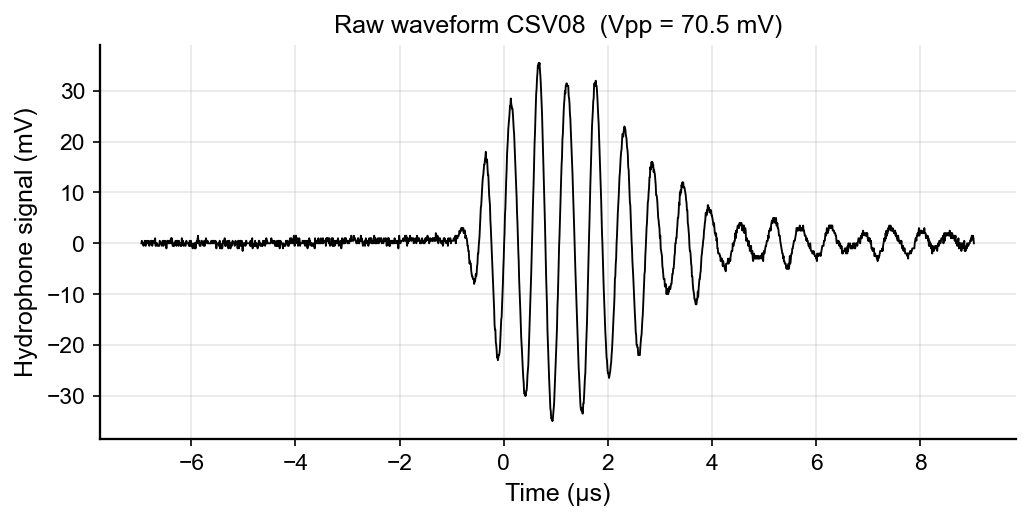

In [11]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# Example raw waveform (time domain) — peak point of the 3D scan (CSV08, X=9, Y=9)
import numpy as np, matplotlib as mpl, matplotlib.pyplot as plt

f = "../data/hydrophone_acoustic_pressure/3D_aneurysm_channel_scan/raw_csv/CSV08_X09_Y09_Z13.csv"
lines = open(f).read().splitlines()
i0 = next(k for k, ln in enumerate(lines) if ln.startswith("TIME"))   # skip scope metadata
arr = np.array([ln.split(",") for ln in lines[i0 + 1:] if ln], dtype=float)
t_us = arr[:, 0] * 1e6      # seconds -> microseconds
v_mV = arr[:, 1] * 1e3      # volts   -> millivolts

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(t_us, v_mV, color="black", lw=0.9)
ax.set_xlabel("Time (µs)"); ax.set_ylabel("Hydrophone signal (mV)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_waveform_CSV08.png"); fig.savefig("hydrophone_figures/hydro_waveform_CSV08.pdf")
plt.show()

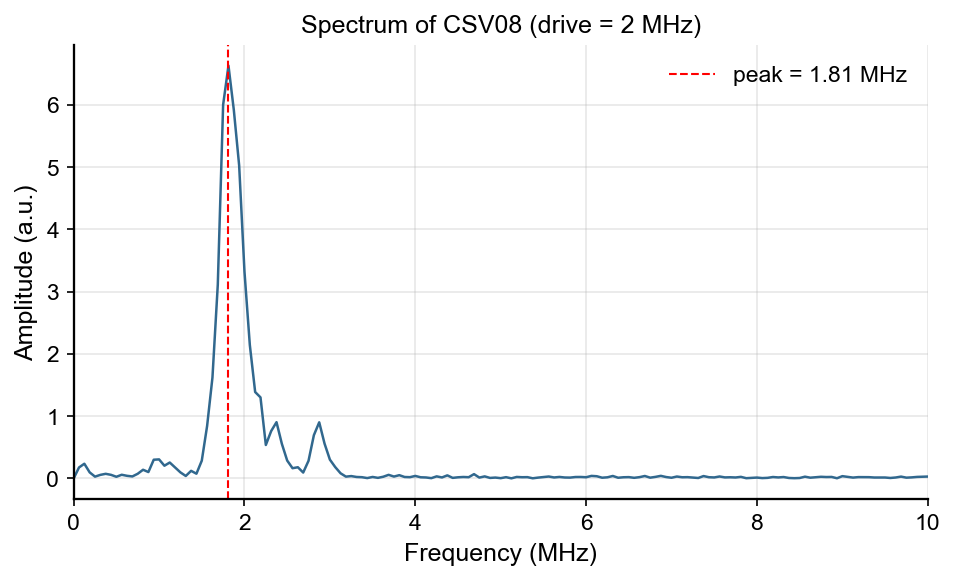

In [12]:
import os
os.makedirs("hydrophone_figures", exist_ok=True)
# Frequency spectrum of the same waveform — should peak at the 2 MHz drive
import numpy as np, matplotlib as mpl, matplotlib.pyplot as plt

f = "../data/hydrophone_acoustic_pressure/3D_aneurysm_channel_scan/raw_csv/CSV08_X09_Y09_Z13.csv"
lines = open(f).read().splitlines()
i0 = next(k for k, ln in enumerate(lines) if ln.startswith("TIME"))
arr = np.array([ln.split(",") for ln in lines[i0 + 1:] if ln], dtype=float)
v = arr[:, 1]
dt = 8e-9                                  # 8 ns sample interval (from scope header)
freq_MHz = np.fft.rfftfreq(v.size, d=dt) / 1e6
amp = np.abs(np.fft.rfft(v - v.mean()))
fpk = freq_MHz[np.argmax(amp)]

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(freq_MHz, amp, color="#31688e", lw=1.2)
ax.axvline(fpk, color="red", ls="--", lw=1, label=f"peak = {fpk:.2f} MHz")
ax.set_xlim(0, 10); ax.set_xlabel("Frequency (MHz)"); ax.set_ylabel("Amplitude (a.u.)")
ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hydrophone_figures/hydro_spectrum_CSV08.png"); fig.savefig("hydrophone_figures/hydro_spectrum_CSV08.pdf")
plt.show()